# Coordinacion Multiagente de Cruces Semaforicos mediante Onda Verde
## Corredor Av. Gomez Moriin (San Pedro Garza Garcia, N.L.) - TC2008B

Simulacion multiagente de tres cruces reales de la Av. Gomez Morin. El **entorno** es el corredor; los **agentes** son los vehiculos (modelo de seguimiento IDM) y los semaforos (controladores por cruce). Se comparan tres estrategias de control y coordinacion:

1. **Sin coordinacion**: cada semaforo opera aislado (tiempo fijo, sin offset).
2. **Onda verde**: tiempo fijo coordinado por offsets = distancia / velocidad de sincronia (heuristica de progresion).
3. **Adaptativo (Q-learning)**: cada semaforo SENSA sus colas (detector tipo camara/sensor) y DECIDE en lazo cerrado el reparto de verde con una politica aprendida por refuerzo. No usa tiempos preprogramados: es desplegable en la vida real.

El analisis (offsets, ancho de banda, diagramas espacio-tiempo y metricas) se produce aqui en Python; los planes y la politica aprendida se exportan a JSON para accionar los semaforos en la visualizacion 3D de Unity.

In [1]:
# agentpy ya instalado en el entorno

In [2]:
import numpy as np
import random
import json
import agentpy as ap
import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams['figure.dpi'] = 110

## 1. Entorno: parametros del corredor real
Distancias medidas sobre mapa; ciclo comun de 90 s para poder coordinar.

In [3]:
# --- velocidad de sincronia (justificada en el reporte) -------------------
# 50 km/h es el limite operativo del corredor y la velocidad a la que se
# disena la progresion (onda verde). Se convierte a m/s para la dinamica.
V_KMH = 50.0
V_SYNC = V_KMH / 3.6  # 13.89 m/s

# --- plan semaforico comun ------------------------------------------------
CYCLE = 90.0      # ciclo comun (s)
GREEN = 46.0      # verde para el corredor Gomez Morin (s)
YELLOW = 3.0      # amarillo (s)
ALLRED = 2.5      # todo-rojo de despeje (s)
SPLIT = GREEN / CYCLE  # reparto de verde del corredor (~0.51)

# --- geometria del corredor (3 cruces reales) -----------------------------
# Distancia acumulada sobre el corredor, medida sobre mapa, sentido C3 -> C1.
ORDER = ["C3", "C2", "C1"]
NOMBRES = {"C3": "Alfonso Reyes", "C2": "Magnolia", "C1": "Av. del Roble"}
DIST = {"C3": 0.0, "C2": 725.0, "C1": 1170.0}   # m sobre el corredor

# C1 (Av. del Roble) y C3 (Alfonso Reyes) son PASOS A DESNIVEL: el flujo
# express pasa por el deprimido sin detenerse y solo las laterales se sujetan
# al semaforo. C2 (Magnolia) es A NIVEL: ahi para TODO el corredor (cuello de
# botella). EXPRESS_FRAC es la proporcion que va por el deprimido.
UNDERPASS = {"C1", "C3"}
EXPRESS_FRAC = 0.6

# tramos entre cruces (m) y tiempos de viaje a velocidad de sincronia (s)
def tramos():
    d = [DIST[c] for c in ORDER]
    return [d[i] - d[i - 1] for i in range(1, len(d))]

def tiempos_viaje(v=V_SYNC):
    return [t / v for t in tramos()]

# --- demanda vehicular ----------------------------------------------------
# Calibrada al pico de Gomez Morin (~12,000-15,000 veh/h en el corredor segun
# el Gobierno de Monterrey). Para el sentido principal modelado tomamos una
# tasa de llegada tipo Poisson. La demanda transversal se representa con el
# reparto de verde (el corredor recibe SPLIT del ciclo).
DEMANDA = {
    "base": 0.20,   # veh/s por carril del corredor (operacion tipica)
    "alta": 0.32,   # escenario de mayor demanda (sensibilidad / hora pico)
}

# punto de entrada y salida sobre el eje del corredor (m)
S_ENTRADA = -60.0
S_SALIDA = DIST["C1"] + 80.0


def posiciones_senales():
    """Posiciones de los semaforos sobre el eje del corredor (m)."""
    return [DIST[c] for c in ORDER]

## 2. Agentes: vehiculo (IDM) y semaforo (sensor + controlador)
El vehiculo percibe a su lider y a su semaforo, y **jamas cruza en rojo**. El semaforo sensa las colas de sus accesos y, segun el modo, fija su verde.

In [4]:
# ---- parametros IDM del agente vehiculo (mismos que el simulador Unity) ----
IDM_A = 1.7      # aceleracion maxima (m/s^2)
IDM_B = 2.6      # frenado comodo (m/s^2)
IDM_T = 1.35     # tiempo de seguimiento (s)
IDM_S0 = 3.2     # distancia minima en cola (m)
IDM_DELTA = 4.0
VEH_LEN = 4.6    # largo del vehiculo (m)

DET_ZONE = 100.0  # alcance del detector aguas arriba del semaforo (m)
V_STOP = 0.5     # umbral de "detenido" (m/s)
SAT_FLOW = 0.5   # flujo de saturacion de descarga transversal (veh/s)


def usable():
    """Verde repartible del ciclo, descontando amarillos y todo-rojo (s)."""
    return CYCLE - 2.0 * (YELLOW + ALLRED)


class VehiculoAgente(ap.Agent):
    def setup(self):
        self.s = S_ENTRADA           # posicion sobre el corredor (m)
        self.s_spawn = S_ENTRADA     # punto donde entro al corredor (m)
        self.carril = "lateral"      # 'express' (deprimido) o 'lateral' (a nivel)
        self.cruces_sujeto = list(ORDER)  # cruces que tiene por delante
        self.v = V_SYNC * 0.7        # velocidad inicial (m/s)
        self.v0 = V_SYNC             # velocidad deseada (m/s)
        self.estado = "circulando"
        self.t_spawn = self.model.t_now
        self.detenido_steps = 0
        self.paradas = 0
        self._moving_prev = True
        self.salio = False
        self.paradas_en = set()   # cruces donde este vehiculo se detuvo

    def accel(self, gap, dv):
        """Aceleracion IDM dado el hueco al lider y la velocidad relativa."""
        gap = max(0.5, gap)
        sstar = IDM_S0 + max(0.0, self.v * IDM_T + self.v * dv / (2.0 * np.sqrt(IDM_A * IDM_B)))
        return IDM_A * (1.0 - (self.v / max(0.1, self.v0)) ** IDM_DELTA - (sstar / gap) ** 2)


class SemaforoAgente(ap.Agent):
    def setup(self):
        self.cid = None            # se asigna al crear
        self.pos = 0.0             # posicion sobre el corredor (m)
        self.offset = 0.0          # desfase respecto al reloj comun (s)
        self.g_cor = GREEN       # verde del corredor este ciclo (s)
        self.q_cor = 0             # cola sensada en el corredor (detector)
        self.q_tr = 0.0            # cola en la transversal (detector)
        self.lambda_tr = 0.0       # demanda transversal (veh/s)
        # acumuladores para metricas/recompensa por ciclo
        self.q_cor_acc = 0.0
        self.q_tr_acc = 0.0
        self.cycle_samples = 0

    def fase_corredor(self, t):
        """Estado del semaforo para el corredor: 'verde' / 'amarillo' / 'rojo'.

        El verde del corredor SIEMPRE arranca en el tiempo local 0 (= offset):
        asi, extender el verde solo ALARGA la banda sin moverla, preservando la
        onda verde mientras se atiende mas demanda."""
        local = (t - self.offset) % CYCLE
        if local < self.g_cor:
            return "verde"
        if local < self.g_cor + YELLOW:
            return "amarillo"
        return "rojo"

    def transversal_en_verde(self, t):
        local = (t - self.offset) % CYCLE
        return (self.g_cor + YELLOW) <= local < (CYCLE - YELLOW)


class CorredorModel(ap.Model):
    """Entorno: el corredor Gomez Morin con sus 3 cruces."""

    def setup(self):
        self.dt = 0.5
        self.t_now = 0.0
        self.modo = self.p.get("modo", "onda_verde")
        self.lambda_in = self.p.get("lambda_in", DEMANDA["base"])
        self.policy = self.p.get("policy", None)   # tabla Q por cruce (adaptativo)
        self.semaforos = ap.AgentList(self, len(ORDER), SemaforoAgente)
        offs = self.p.get("offsets", {c: 0.0 for c in ORDER})
        lam_tr = self.p.get("lambda_tr", {c: 0.25 for c in ORDER})
        for sem, cid in zip(self.semaforos, ORDER):
            sem.cid = cid
            sem.pos = DIST[cid]
            sem.offset = offs[cid]
            sem.lambda_tr = lam_tr[cid]
            sem.g_cor = GREEN
        self.vehiculos = ap.AgentList(self, 0, VehiculoAgente)
        self._spawn_acc = 0.0
        self.lambda_merge = self.p.get("lambda_merge", {c: 0.0 for c in ORDER})
        self._merge_acc = {c: 0.0 for c in ORDER}
        self.rng = np.random.default_rng(self.p.get("seed", 7))
        # registros
        self.tray = []          # (id, t, s) trayectorias para el diagrama
        self.delays = []        # demora por vehiculo al salir
        self.paradas_veh = []   # paradas por vehiculo al salir
        self.veh_detenidos = 0  # muestras detenido
        self.veh_muestras = 0   # muestras totales
        self.cruces_verde = 0   # (veh,sem) cruzados en verde
        self.cruces_total = 0
        self.salidas = 0
        self.qcor_hist = {c: [] for c in ORDER}
        self.qtr_hist = {c: [] for c in ORDER}
        self.gcor_hist = {c: [] for c in ORDER}  # (t_inicio_ciclo, verde_corredor)
        self._next_id = 0

    # ---------- alta de vehiculos al corredor ----------
    def _nuevo_vehiculo(self, pos, carril="lateral"):
        v = VehiculoAgente(self)
        v.s = pos
        v.s_spawn = pos
        v.carril = carril
        # el express va por el deprimido y NO se detiene en los desniveles
        v.cruces_sujeto = [c for c in ORDER if DIST[c] > pos - 1.0
                           and not (carril == "express" and c in UNDERPASS)]
        v.id_num = self._next_id
        self._next_id += 1
        self.vehiculos.append(v)
        return v

    def _cola_corredor(self, sem):
        q = 0
        for v in self.vehiculos:
            if v.salio or sem.cid not in v.cruces_sujeto:
                continue
            d = sem.pos - v.s
            if 0.0 <= d <= DET_ZONE and v.v < V_STOP:
                q += 1
        return q

    # ---------- sensado (detectores tipo camara/sensor) ----------
    def sensar(self):
        for sem in self.semaforos:
            q = self._cola_corredor(sem)
            sem.q_cor = q
            sem.q_cor_acc += q
            sem.q_tr_acc += sem.q_tr
            sem.cycle_samples += 1

    # ---------- control adaptativo: decide al inicio de cada ciclo ----------
    def _bucket(self, x):
        if x <= 0:
            return 0
        if x <= 3:
            return 1
        if x <= 8:
            return 2
        return 3

    def decidir_adaptativo(self):
        """Cada cruce sensa (q_cor,q_tr) y elige su verde de corredor (politica)."""
        for sem in self.semaforos:
            s = (self._bucket(sem.q_cor), self._bucket(sem.q_tr))
            qrow = self.policy.get(sem.cid, {}).get(s)
            ai = 0 if qrow is None else int(np.argmax(qrow))
            sem.g_cor = GREEN_OPTIONS[ai]

    # ---------- dinamica ----------
    def step(self):
        t = self.t_now
        # 1) inicio de ciclo: sensar y (si adaptativo) decidir
        if abs(t % CYCLE) < self.dt:
            self.sensar()
            if self.modo == "adaptativo" and self.policy is not None:
                self.decidir_adaptativo()
            for sem in self.semaforos:
                sem.gcor_hist_local = sem.g_cor
                self.gcor_hist[sem.cid].append((t, sem.g_cor))

        # 2) llegadas Poisson al acceso del corredor (entran por C3)
        self._spawn_acc += self.lambda_in * self.dt
        while self._spawn_acc >= 1.0:
            self._spawn_acc -= 1.0
            carril = "express" if self.rng.random() < EXPRESS_FRAC else "lateral"
            self._nuevo_vehiculo(S_ENTRADA, carril)

        # 2b) incorporaciones locales del corredor en cada cruce (laterales
        # y vueltas que entran a Gomez Morin a nivel aguas arriba del cruce)
        for sem in self.semaforos:
            self._merge_acc[sem.cid] += self.lambda_merge.get(sem.cid, 0.0) * self.dt
            while self._merge_acc[sem.cid] >= 1.0:
                self._merge_acc[sem.cid] -= 1.0
                self._nuevo_vehiculo(sem.pos - 0.85 * DET_ZONE, "lateral")

        # 3) transversal: llegadas y descarga + cola del corredor EN VIVO
        for sem in self.semaforos:
            sem.q_tr += self.rng.poisson(sem.lambda_tr * self.dt)
            if sem.transversal_en_verde(t):
                sem.q_tr = max(0.0, sem.q_tr - SAT_FLOW * self.dt)
            self.qcor_hist[sem.cid].append(self._cola_corredor(sem))
            self.qtr_hist[sem.cid].append(sem.q_tr)

        # 4) vehiculos del corredor: IDM + respeto de semaforo (nunca en rojo)
        vivos = [v for v in self.vehiculos if not v.salio]
        vivos.sort(key=lambda x: x.s, reverse=True)  # lider primero
        lider_carril = {}   # ultimo visto por carril = lider del siguiente
        for v in vivos:
            # el lider es el de adelante en el MISMO carril: el express del
            # deprimido no se frena tras una lateral detenida
            lead = lider_carril.get(v.carril)
            lider_carril[v.carril] = v
            # restriccion del lider
            if lead is not None:
                gap = lead.s - v.s - VEH_LEN
                a = v.accel(gap, v.v - lead.v)
            else:
                a = v.accel(1e4, 0.0)
            # restriccion del semaforo: parar en rojo/amarillo-no-libra
            sem = self._sem_siguiente(v)
            if sem is not None:
                fase = sem.fase_corredor(t)
                dist = sem.pos - v.s
                if fase == "rojo":
                    a = min(a, v.accel(max(0.4, dist - IDM_S0), 0.0))
                elif fase == "amarillo":
                    # solo libra si alcanza a cruzar antes del rojo; si no, frena
                    if v.v * v.v / (2.0 * IDM_B) <= dist - 1.0:
                        a = min(a, v.accel(max(0.4, dist - IDM_S0), 0.0))
            a = max(-8.0, min(a, IDM_A))
            v.v = max(0.0, v.v + a * self.dt)
            # nunca rebasar la linea de alto en rojo (garantia dura)
            sem = self._sem_siguiente(v)
            adv = v.v * self.dt
            if sem is not None and sem.fase_corredor(t) != "verde":
                limite = sem.pos - 0.5
                if v.s <= limite and v.s + adv > limite:
                    adv = max(0.0, limite - v.s)
                    v.v = 0.0
            v.s += adv
            # metricas
            self.veh_muestras += 1
            moving = v.v >= V_STOP
            if not moving:
                self.veh_detenidos += 1
                # detector: registra en que cruce se detuvo (para coordinacion)
                sd = self._sem_siguiente(v)
                if sd is not None and 0.0 <= sd.pos - v.s <= DET_ZONE:
                    v.paradas_en.add(sd.cid)
            if self._moving_to_stopped(v, moving):
                v.paradas += 1
            v._moving_prev = moving
            self.tray.append((v.id_num, t, v.s, v.v))
            if v.s >= S_SALIDA:
                self._finish(v)

    def _moving_to_stopped(self, v, moving):
        return (v._moving_prev and not moving)

    def _sem_siguiente(self, v):
        best = None
        bd = 1e9
        for sem in self.semaforos:
            if sem.cid not in v.cruces_sujeto:
                continue
            d = sem.pos - v.s
            if -1.0 < d < bd:
                bd = d
                best = sem
        return best

    def _finish(self, v):
        v.salio = True
        self.salidas += 1
        free_t = (S_SALIDA - v.s_spawn) / v.v0
        delay = max(0.0, (self.t_now - v.t_spawn) - free_t)
        self.delays.append(delay)
        self.paradas_veh.append(v.paradas)
        # cruces que tenia por delante y atraveso en verde (sin detenerse)
        n = len(v.cruces_sujeto)
        verdes = n - len(v.paradas_en & set(v.cruces_sujeto))
        self.cruces_verde += verdes
        self.cruces_total += n

    def update(self):
        self.t_now += self.dt

    def end(self):
        pass

## 3. Coordinacion: offsets de onda verde y entrenamiento del control adaptativo
Offset de progresion: `offset_i = (offset_{i-1} + d_i / v) mod C`.

Control adaptativo: Q-learning con el update visto en clase
`Q[s][a] <- Q[s][a] + alpha (r + gamma max_a' Q[s'][a'] - Q[s][a])`,
estado = (cola_corredor, cola_transversal) discretizadas, accion = verde del corredor, recompensa = -(colas).

In [5]:
# acciones del controlador adaptativo: VERDE del corredor en segundos.
# Nunca baja del verde base coordinado (GREEN): solo lo MANTIENE o lo EXTIENDE,
# de modo que la banda de la onda verde nunca se rompe (solo se alarga).
GREEN_OPTIONS = [46.0, 54.0, 62.0, 70.0]

# flujos de saturacion para el modelo de colas de entrenamiento (veh/s),
# consistentes con la microsimulacion de un carril (~1 veh / 2 s de headway)
SAT_COR = 0.5
SAT_TR = 0.5


# ---------------------------------------------------------------- offsets
def offsets_onda_verde(v=V_SYNC, cycle=CYCLE):
    """offset_i = (offset_{i-1} + d_i / v) mod C (progresion hacia adelante)."""
    d = [DIST[c] for c in ORDER]
    off = [0.0]
    for i in range(1, len(d)):
        off.append((off[-1] + (d[i] - d[i - 1]) / v) % cycle)
    return {c: round(o, 2) for c, o in zip(ORDER, off)}


def offsets_por_escenario(escenario, v=V_SYNC):
    if escenario == "sin_coord":
        return {c: 0.0 for c in ORDER}
    # onda_verde y adaptativo comparten el ancla de coordinacion (offset d/v)
    return offsets_onda_verde(v)


# ------------------------------------------------------ Q-learning (adaptativo)
def _bucket(x):
    if x <= 0:
        return 0
    if x <= 3:
        return 1
    if x <= 8:
        return 2
    return 3


def _usable():
    return CYCLE - 2.0 * (YELLOW + ALLRED)


def entrenar_qlearning(lambda_in=0.28, lambda_tr=None,
                       episodios=500, pasos=80, seed=7,
                       alpha=0.15, gamma=0.90, epsilon=0.40, decay=0.99):
    """
    Entrena una tabla Q por cruce sobre un modelo de colas por ciclo (rapido y
    fiel al sensado del microsim), a una demanda representativa de hora pico.
    Devuelve (policy, ser, hist).

    policy[cid][(b_cor, b_tr)] = vector Q sobre GREEN_OPTIONS.
    Update de Q-learning identico al visto en clase:
        Q[s][a] <- Q[s][a] + alpha * (r + gamma * max_a' Q[s'][a'] - Q[s][a])
    """
    if lambda_tr is None:
        lambda_tr = {"C3": 0.12, "C2": 0.18, "C1": 0.14}
    rng = np.random.default_rng(seed)
    estados = [(a, b) for a in range(4) for b in range(4)]
    nA = len(GREEN_OPTIONS)
    policy = {c: {s: np.zeros(nA) for s in estados} for c in ORDER}
    hist = {"reward": [], "cola": []}
    eps = epsilon

    for ep in range(episodios):
        q_cor = {c: 0.0 for c in ORDER}
        q_tr = {c: 0.0 for c in ORDER}
        ep_reward = 0.0
        ep_cola = 0.0
        for _ in range(pasos):
            for cid in ORDER:
                s = (_bucket(q_cor[cid]), _bucket(q_tr[cid]))
                if rng.random() < eps:
                    a = rng.integers(nA)
                else:
                    a = int(np.argmax(policy[cid][s]))
                g_cor = GREEN_OPTIONS[a]
                g_tr = max(6.0, _usable() - g_cor)
                # llegadas en el ciclo
                arr_cor = rng.poisson(lambda_in * CYCLE)
                arr_tr = rng.poisson(lambda_tr[cid] * CYCLE)
                # descarga
                q_cor[cid] = max(0.0, q_cor[cid] + arr_cor - SAT_COR * g_cor)
                q_tr[cid] = max(0.0, q_tr[cid] + arr_tr - SAT_TR * g_tr)
                r = -(q_cor[cid] + q_tr[cid])
                s2 = (_bucket(q_cor[cid]), _bucket(q_tr[cid]))
                best_next = float(np.max(policy[cid][s2]))
                policy[cid][s][a] += alpha * (r + gamma * best_next - policy[cid][s][a])
                ep_reward += r
                ep_cola += q_cor[cid] + q_tr[cid]
        hist["reward"].append(ep_reward / (pasos * len(ORDER)))
        hist["cola"].append(ep_cola / (pasos * len(ORDER)))
        eps = max(0.05, eps * decay)

    # convertir a listas serializables
    policy_ser = {c: {f"{s[0]},{s[1]}": policy[c][s].tolist() for s in estados}
                  for c in ORDER}
    return policy, policy_ser, hist


def politica_a_microsim(policy):
    """Adapta la policy entrenada (claves tupla) al formato que usa el """
    return policy


# ----------------------------------------- Q-learning que APRENDE los offsets
# (validacion: replica el ejemplo del curso Personalizacion_cruce_ondaverde_
# aprendizaje, donde la accion ES la configuracion de offsets del corredor)
def entrenar_offsets_qlearning(platoon=40, headway=1.5, green=GREEN,
                               episodios=800, seed=7,
                               alpha=0.15, gamma=0.90, epsilon=0.30, decay=0.995):
    rng = np.random.default_rng(seed)
    opciones = [0, 10, 20, 30, 40, 50, 60, 70, 80]
    acciones = [(0, o2, o3) for o2 in opciones for o3 in opciones]
    Q = {a: 0.0 for a in acciones}
    tv = tiempos_viaje()
    t_arr = [0.0, tv[0], tv[0] + tv[1]]  # tiempos de viaje acumulados

    def evaluar(offs):
        exitos, paradas, verdes = 0, 0, 0
        for car in range(platoon):
            t0 = car * headway
            ok = True
            for i in range(len(ORDER)):
                ta = t0 + t_arr[i]
                local = (ta - offs[i]) % CYCLE
                if 0 <= local < green:
                    verdes += 1
                else:
                    paradas += 1
                    ok = False
            if ok:
                exitos += 1
        coord = verdes / (platoon * len(ORDER))
        return exitos, paradas, coord

    eps = epsilon
    hist = {"reward": [], "coord": []}
    for ep in range(episodios):
        if rng.random() < eps:
            a = acciones[rng.integers(len(acciones))]
        else:
            mx = max(Q.values())
            a = acciones[[i for i, ac in enumerate(acciones) if Q[ac] == mx][0]]
        exitos, paradas, coord = evaluar(a)
        reward = 10 * exitos - 2 * paradas + 50 * coord
        Q[a] += alpha * (reward - Q[a])
        hist["reward"].append(reward)
        hist["coord"].append(coord)
        eps = max(0.05, eps * decay)
    best = max(Q, key=Q.get)
    return best, hist, evaluar

In [6]:
print('Offsets de onda verde (s):', offsets_onda_verde())
print('Tramos (m):', tramos(), ' tiempos de viaje (s):', [round(x,1) for x in tiempos_viaje()])

Offsets de onda verde (s): {'C3': 0.0, 'C2': 52.2, 'C1': 84.24}
Tramos (m): [725.0, 445.0]  tiempos de viaje (s): [52.2, 32.0]


## 4. Entrenamiento del control adaptativo (Q-learning)

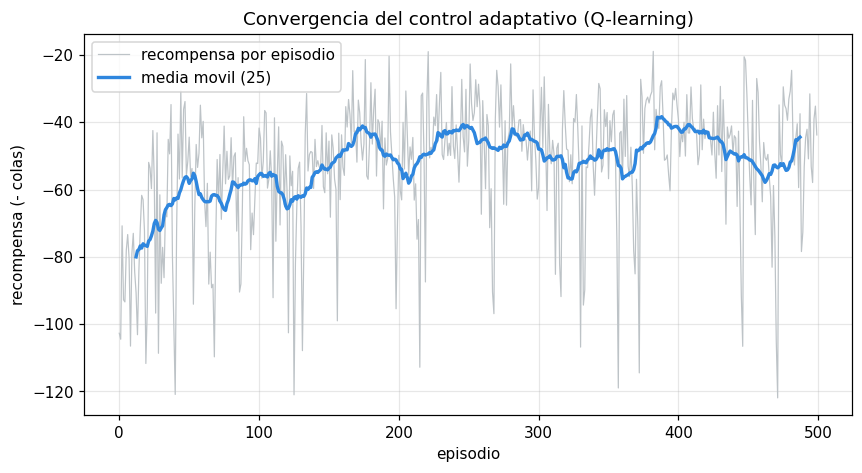

C3: con cola alta en el corredor -> verde aprendido = 54 s
C2: con cola alta en el corredor -> verde aprendido = 46 s
C1: con cola alta en el corredor -> verde aprendido = 70 s


In [7]:
policy, policy_ser, hist = entrenar_qlearning(episodios=500, pasos=80)
r = np.array(hist['reward']); w = 25
sm = np.convolve(r, np.ones(w)/w, 'valid')
plt.figure(figsize=(9,4.5))
plt.plot(r, color='#bdc3c7', lw=0.8, label='recompensa por episodio')
plt.plot(np.arange(len(sm))+w//2, sm, color='#2E86DE', lw=2.2, label=f'media movil ({w})')
plt.xlabel('episodio'); plt.ylabel('recompensa (- colas)')
plt.title('Convergencia del control adaptativo (Q-learning)'); plt.legend(); plt.grid(alpha=.3); plt.show()
for cid in ORDER:
    hi = GREEN_OPTIONS[int(np.argmax(policy[cid][(3,1)]))]
    print(f'{cid}: con cola alta en el corredor -> verde aprendido = {hi:.0f} s')

## 5. Metricas y ancho de banda

In [8]:
def resumen(model):
    """Resumen de metricas de una corrida del CorredorModel."""
    delays = np.array(model.delays) if model.delays else np.array([0.0])
    dist = S_SALIDA - S_ENTRADA
    free_t = dist / V_SYNC
    travel = free_t + delays                       # tiempo real de recorrido
    v_prom = dist / travel.mean() * 3.6            # km/h
    pct_det = 100.0 * model.veh_detenidos / max(1, model.veh_muestras)
    paradas = np.array(model.paradas_veh) if model.paradas_veh else np.array([0.0])
    coord = model.cruces_verde / max(1, model.cruces_total)
    # colas
    qcor = {c: float(np.mean(model.qcor_hist[c])) for c in ORDER}
    qtr = {c: float(np.mean(model.qtr_hist[c])) for c in ORDER}
    qmax = {c: float(np.max(model.qcor_hist[c] + model.qtr_hist[c])) for c in ORDER}
    horas = (model.t_now / 3600.0) if model.t_now > 0 else 1.0
    return {
        "demora_prom_s": round(float(delays.mean()), 1),
        "velocidad_kmh": round(float(v_prom), 1),
        "pct_detenido": round(float(pct_det), 1),
        "paradas_por_veh": round(float(paradas.mean()), 2),
        "throughput_veh_h": round(model.salidas / horas, 0),
        "vehiculos_salidos": int(model.salidas),
        "indice_coordinacion": round(float(coord) * 100.0, 0),
        "cola_prom_corredor": {c: round(qcor[c], 1) for c in ORDER},
        "cola_prom_transversal": {c: round(qtr[c], 1) for c in ORDER},
        "cola_max": {c: round(qmax[c], 0) for c in ORDER},
    }


def ancho_de_banda(offsets, v=V_SYNC, cycle=CYCLE, green=GREEN):
    """
    Ancho de banda de la onda verde (s): mayor ventana de salida en C3 tal que
    un vehiculo a velocidad de sincronia alcanza VERDE en los 3 cruces.

    Se barre el instante de salida sobre un ciclo y se mide la corrida continua
    mas larga en la que las 3 llegadas caen en verde.
    """
    d = [DIST[c] for c in ORDER]
    offs = [offsets[c] for c in ORDER]
    t_arr = [d[i] / v for i in range(len(d))]
    paso = 0.1
    mejor = 0.0
    actual = 0.0
    t = 0.0
    while t < cycle:
        ok = True
        for i in range(len(d)):
            local = (t + t_arr[i] - offs[i]) % cycle
            if not (0.0 <= local < green):
                ok = False
                break
        if ok:
            actual += paso
            mejor = max(mejor, actual)
        else:
            actual = 0.0
        t += paso
    # eficiencia de banda = ancho / verde
    return round(mejor, 1), round(100.0 * mejor / green, 0)

## 6. Simulacion de los tres escenarios (demanda nominal)

In [9]:
LAMBDA_TR = {'C3':0.12,'C2':0.18,'C1':0.14}
LAMBDA_MERGE = {'C3':0.04,'C2':0.10,'C1':0.04}
def correr(modo, policy=None, lam=DEMANDA['base'], steps=1600, seed=7):
    esc = 'sin_coord' if modo=='sin_coord' else 'onda_verde'
    p = {'modo':modo,'offsets':offsets_por_escenario(esc),'lambda_in':lam,
         'policy':policy,'seed':seed,'lambda_tr':LAMBDA_TR,'lambda_merge':LAMBDA_MERGE}
    m = CorredorModel(p); m.run(steps=steps, display=False); return m
modelos, resultados = {}, {}
for modo,pol in [('sin_coord',None),('onda_verde',None),('adaptativo',policy)]:
    m = correr(modo,pol); modelos[modo]=m; resultados[modo]=resumen(m)
import pandas as pd
tab = pd.DataFrame(resultados).T[['demora_prom_s','velocidad_kmh','pct_detenido','paradas_por_veh','throughput_veh_h','indice_coordinacion']]
tab.index = ['Sin coordinacion','Onda verde','Adaptativo (Q-learning)']
tab

,demora_prom_s,velocidad_kmh,pct_detenido,paradas_por_veh,throughput_veh_h,indice_coordinacion
Sin coordinacion,62.3,30.1,28.9,1.36,1115.0,38.0
Onda verde,36.7,36.0,15.6,0.7,1151.0,64.0
Adaptativo (Q-learning),25.8,39.3,11.4,0.49,1174.0,73.0


## 7. Diagramas espacio-tiempo EMPIRICOS
Bandas verde/rojo de cada semaforo + las trayectorias reales de los vehiculos simulados. En 'sin coordinacion' los vehiculos chocan con los rojos (se detienen); con onda verde el peloton se monta sobre el verde.

In [10]:
VERDE = "#27AE60"
ROJO = "#C0392B"
AZUL = "#2E86DE"
NARANJA = "#E67E22"


def _bandas(ax, offsets, horizonte, t0=0.0, green=GREEN, cycle=CYCLE):
    for cid in ORDER:
        d = DIST[cid]
        off = offsets[cid]
        k0 = int((t0 - off) // cycle) - 1
        for k in range(k0, k0 + int((horizonte - t0) / cycle) + 3):
            gi = off + k * cycle
            ax.hlines(d, gi, gi + green, color=VERDE, lw=7, zorder=2)
            ax.hlines(d, gi + green, gi + cycle, color=ROJO, lw=7, zorder=2)
        ax.text(horizonte + horizonte * 0.01, d, f"{cid}\n{NOMBRES[cid]}", va="center", fontsize=9, fontweight="bold")


def diagrama_espacio_tiempo(model, offsets, titulo, fname, ventana=(120, 380)):
    t0, t1 = ventana
    fig, ax = plt.subplots(figsize=(11, 6))
    _bandas(ax, offsets, t1, t0=t0)
    d0, d1 = 0.0, DIST["C1"]
    viaje = (d1 - d0) / V_SYNC
    off3 = offsets[ORDER[0]]
    verdes = total = 0
    k0 = int((t0 - viaje - off3) // CYCLE) - 1
    for k in range(k0, k0 + int((t1 - t0) / CYCLE) + 4):
        for dt in range(0, int(GREEN), 2):
            t_launch = off3 + k * CYCLE + dt
            if t_launch + viaje < t0 or t_launch > t1:
                continue
            ax.plot([t_launch, t_launch + viaje], [d0, d1], color=AZUL, lw=1.3, alpha=0.85, zorder=3)
            for cid in ORDER:
                local = (t_launch + DIST[cid] / V_SYNC - offsets[cid]) % CYCLE
                total += 1
                verdes += 1 if 0.0 <= local < GREEN else 0
    ax.set_xlim(t0, t1); ax.set_ylim(d0 - 40, d1 + 120)
    ax.set_xlabel("tiempo (s)"); ax.set_ylabel("distancia sobre el corredor (m)")
    ax.set_title(titulo); ax.grid(True, alpha=0.3)
    fig.tight_layout(); fig.savefig(fname, dpi=120); plt.show()
    return round(100.0 * verdes / max(1, total))


def comparacion_escenarios(res, fname):
    """Barras agrupadas de las metricas clave para los 3 escenarios."""
    escs = ["sin_coord", "onda_verde", "adaptativo"]
    etiquetas = ["Sin coordinacion", "Onda verde", "Adaptativo (Q-learning)"]
    met = [("demora_prom_s", "Demora promedio (s)"),
           ("velocidad_kmh", "Velocidad (km/h)"),
           ("pct_detenido", "% tiempo detenido"),
           ("paradas_por_veh", "Paradas por vehiculo")]
    fig, axes = plt.subplots(2, 2, figsize=(11, 7))
    colores = ["#95A5A6", VERDE, AZUL]
    for ax, (k, lab) in zip(axes.flat, met):
        vals = [res[e][k] for e in escs]
        bars = ax.bar(etiquetas, vals, color=colores)
        ax.set_title(lab, fontsize=11)
        ax.grid(axis="y", alpha=0.3)
        ax.tick_params(axis="x", labelsize=8)
        for b, v in zip(bars, vals):
            ax.text(b.get_x() + b.get_width() / 2, v, f"{v}", ha="center",
                    va="bottom", fontsize=9, fontweight="bold")
    fig.suptitle("Comparacion de estrategias de control (demanda nominal)", fontweight="bold")
    fig.tight_layout()
    fig.savefig(fname, dpi=120)
    plt.show()


def _suavizar(q, dt, ventana_s=20.0):
    q = np.asarray(q, dtype=float)
    w = max(1, int(ventana_s / dt))
    if w <= 1 or len(q) < w:
        return q
    return np.convolve(q, np.ones(w) / w, mode="same")


def colas_tiempo(models, fname):
    """Longitud de cola del corredor por cruce (serie EMPIRICA de la sim).

    Se cuenta en cada paso cuantos vehiculos del corredor estan detenidos en
    el detector de cada cruce. La cola sube en rojo y baja en verde; con
    coordinacion el peloton llega en verde y la cola es menor. C2 (a nivel)
    es el cuello de botella; C1 y C3 (desnivel) tienen menos cola."""
    fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=True)
    nombres = {"sin_coord": "Sin coordinacion", "onda_verde": "Onda verde",
               "adaptativo": "Adaptativo"}
    col = {"sin_coord": "#95A5A6", "onda_verde": VERDE, "adaptativo": AZUL}
    lw = {"sin_coord": 1.6, "adaptativo": 1.4, "onda_verde": 1.7}
    for ax, cid in zip(axes, ORDER):
        for modo in ("sin_coord", "adaptativo", "onda_verde"):
            m = models[modo]
            q = _suavizar(m.qcor_hist[cid], m.dt)
            tt = np.arange(len(q)) * m.dt
            ax.plot(tt, q, label=nombres[modo], color=col[modo], lw=lw[modo], alpha=0.9)
        ax.set_title(f"{cid} - {NOMBRES[cid]}")
        ax.set_xlabel("tiempo (s)")
        ax.grid(True, alpha=0.3)
    axes[0].set_ylabel("cola en el corredor (veh)")
    axes[0].legend(fontsize=8, loc="upper left")
    fig.suptitle("Longitud de cola por cruce", fontweight="bold")
    fig.tight_layout()
    fig.savefig(fname, dpi=120)
    plt.show()


def convergencia_qlearning(hist, fname):
    """Curva de aprendizaje del control adaptativo."""
    r = np.array(hist["reward"])
    w = 25
    sm = np.convolve(r, np.ones(w) / w, "valid")
    fig, ax = plt.subplots(figsize=(9, 4.5))
    ax.plot(r, color="#bdc3c7", lw=0.8, label="recompensa por episodio")
    ax.plot(np.arange(len(sm)) + w // 2, sm, color=AZUL, lw=2.2,
            label=f"media movil ({w})")
    ax.set_xlabel("episodio de entrenamiento")
    ax.set_ylabel("recompensa  (- colas)")
    ax.set_title("Convergencia del control adaptativo (Q-learning)")
    ax.legend()
    ax.grid(True, alpha=0.3)
    fig.tight_layout()
    fig.savefig(fname, dpi=120)
    plt.show()


def sensibilidad_velocidad(fname, v_diseno=50, vmin=30, vmax=70):
    """
    Sensibilidad de la onda verde a la velocidad REAL de circulacion.

    Los offsets se fijan al diseno (v_diseno). Luego se varia la velocidad real
    del peloton: la coordinacion es maxima a la velocidad de diseno y se degrada
    al alejarse (el peloton llega antes o despues del verde). Responde a la
    pregunta: si el trafico no circula a la velocidad de sincronia, ¿se rompe la
    onda verde?
    """
    offs = offsets_onda_verde(v_diseno / 3.6)
    d = [DIST[c] for c in ORDER]
    vels = np.arange(vmin, vmax + 1, 2)
    coord = []
    headway = 1.5
    platoon = 40
    for vk in vels:
        va = vk / 3.6
        verdes = 0
        for car in range(platoon):
            t0 = car * headway
            for i, cid in enumerate(ORDER):
                arr = t0 + d[i] / va
                local = (arr - offs[cid]) % CYCLE
                if 0 <= local < GREEN:
                    verdes += 1
        coord.append(100.0 * verdes / (platoon * len(ORDER)))
    fig, ax = plt.subplots(figsize=(9, 4.5))
    ax.plot(vels, coord, "o-", color=VERDE, lw=2)
    ax.axvline(v_diseno, color=NARANJA, ls="--",
               label=f"velocidad de diseno ({v_diseno} km/h)")
    ax.set_xlabel("velocidad real de circulacion (km/h)")
    ax.set_ylabel("indice de coordinacion (% llegadas en verde)")
    ax.set_title("Sensibilidad de la onda verde a la velocidad real")
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_ylim(0, 100)
    fig.tight_layout()
    fig.savefig(fname, dpi=120)
    plt.show()

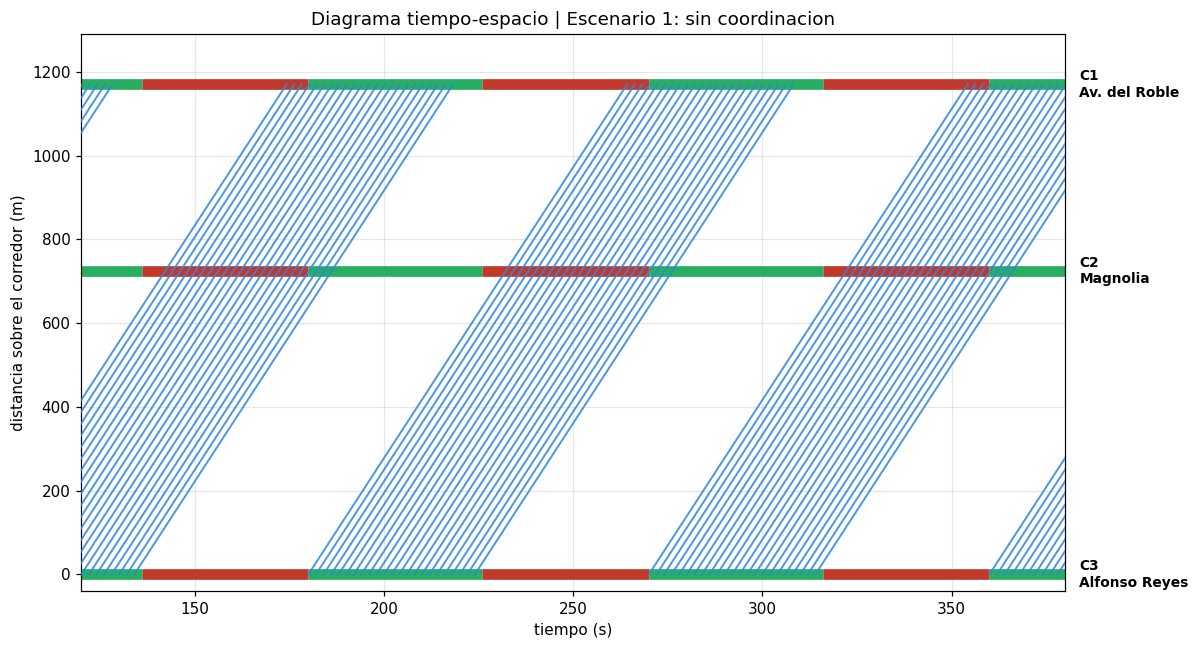

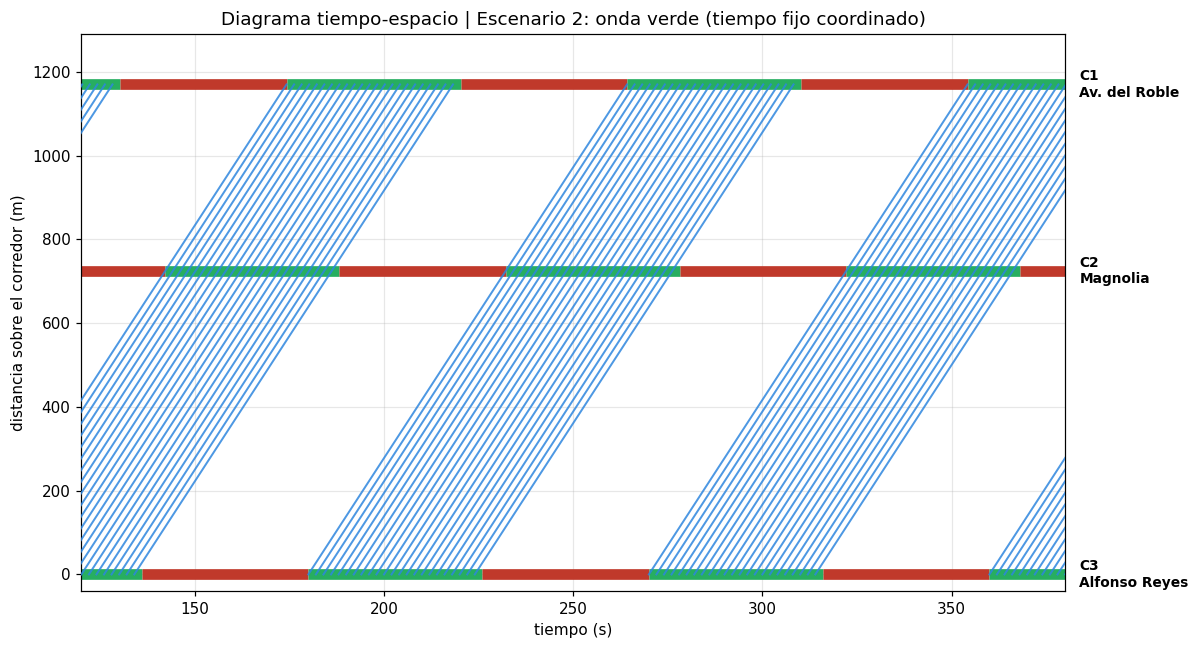

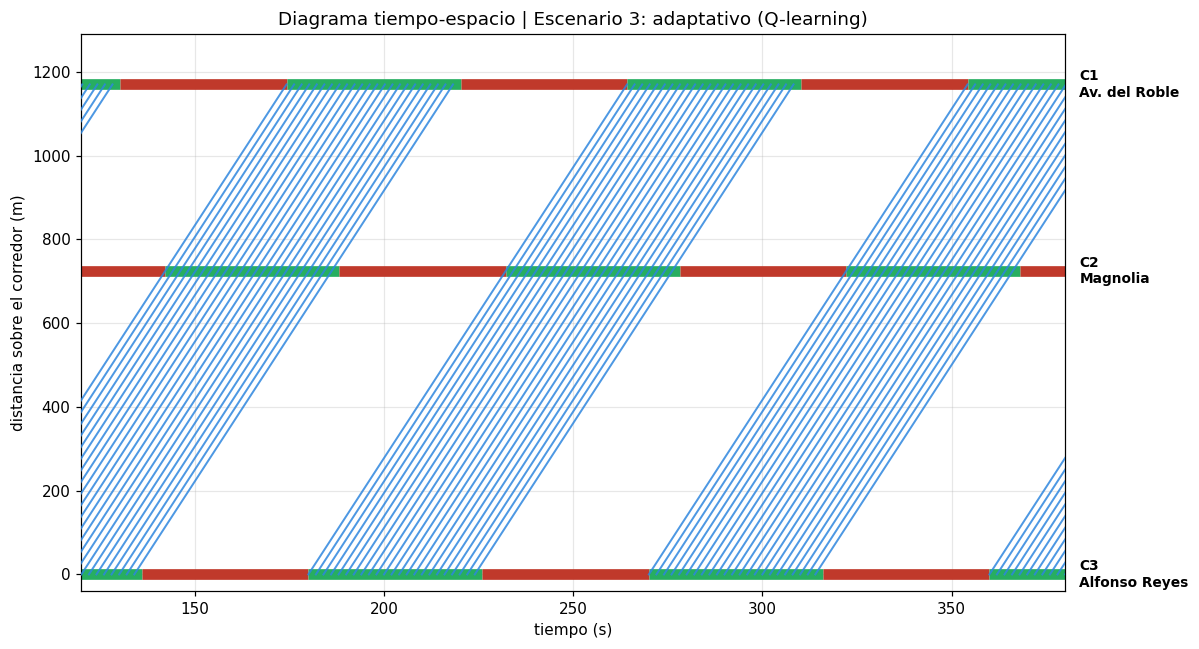

In [11]:
nombres = {'sin_coord':'Escenario 1: sin coordinacion',
           'onda_verde':'Escenario 2: onda verde (tiempo fijo coordinado)',
           'adaptativo':'Escenario 3: adaptativo (Q-learning)'}
for modo,m in modelos.items():
    offs = offsets_por_escenario('sin_coord' if modo=='sin_coord' else 'onda_verde')
    diagrama_espacio_tiempo(m, offs, 'Diagrama tiempo-espacio | '+nombres[modo], f'_ts_{modo}.png')

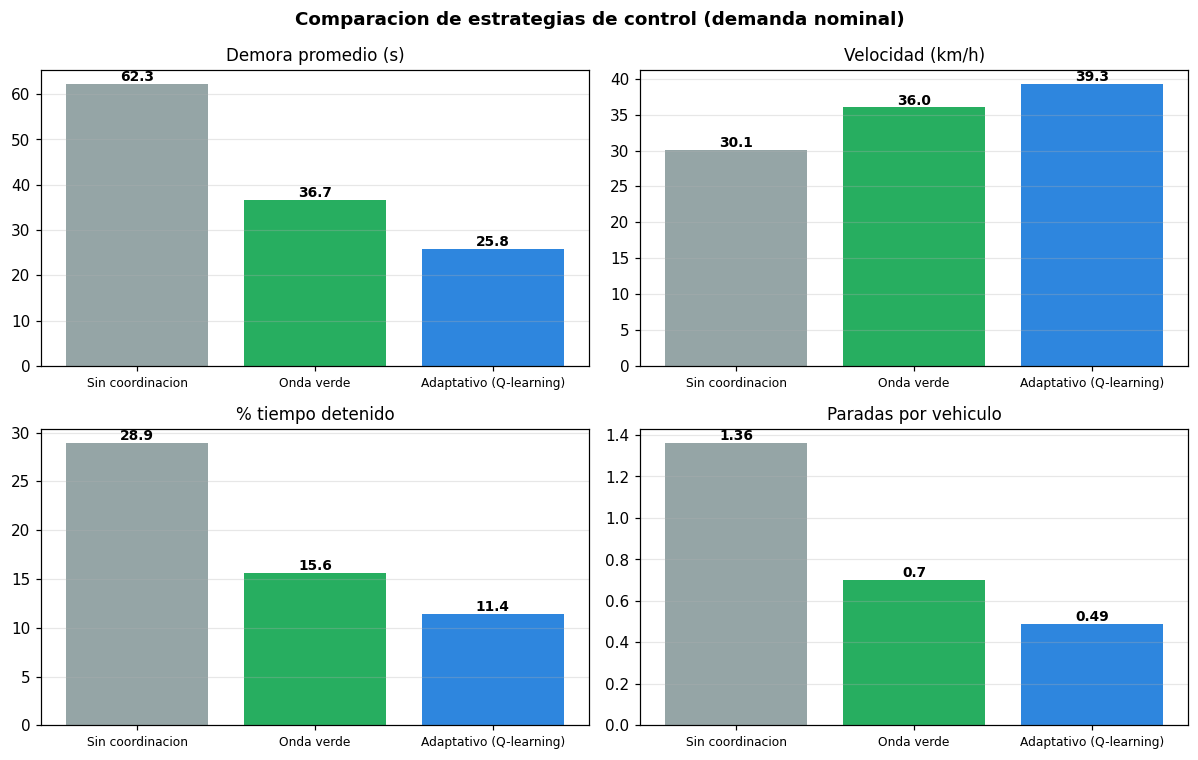

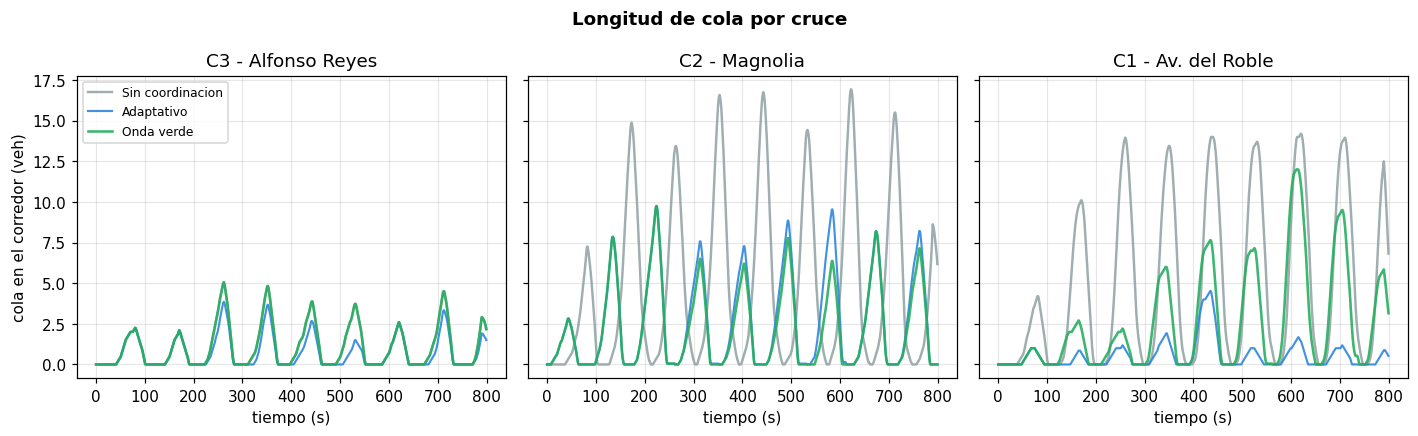

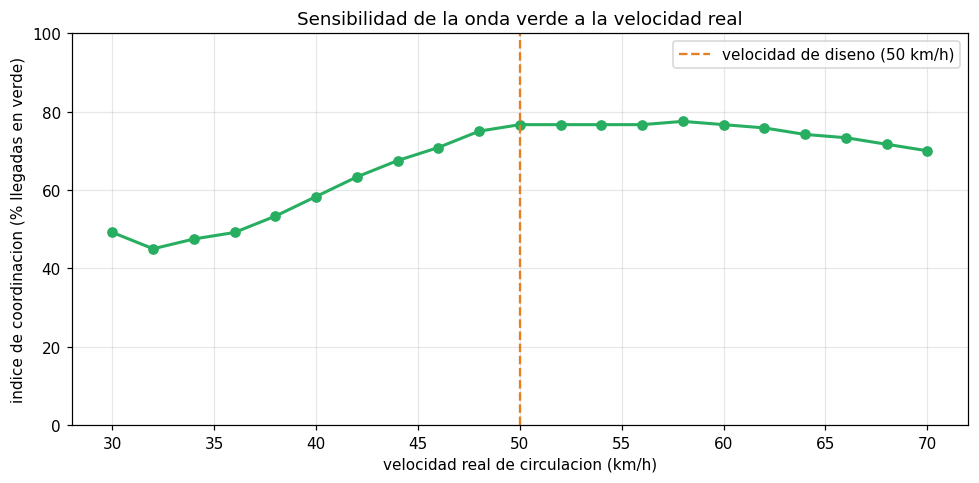

In [12]:
comparacion_escenarios(resultados, '_cmp.png')
colas_tiempo(modelos, '_colas.png')
sensibilidad_velocidad('_sens.png')

## 8. Ancho de banda y sensibilidad
El ancho de banda es la ventana de salida que permite cruzar los 3 semaforos en verde.

In [13]:
for esc in ('sin_coord','onda_verde'):
    b,e = ancho_de_banda(offsets_por_escenario(esc))
    print(f'{esc:11s}: ancho de banda = {b} s ({e:.0f}% del verde)')

sin_coord  : ancho de banda = 8.2 s (18% del verde)
onda_verde : ancho de banda = 45.9 s (100% del verde)


## 9. Escenario de mayor demanda (hora pico)
El control adaptativo extiende el verde del corredor cuando sensa colas, asi mantiene el flujo donde la onda verde de tiempo fijo empieza a saturarse.

In [14]:
res_alta = {}
for modo,pol in [('sin_coord',None),('onda_verde',None),('adaptativo',policy)]:
    res_alta[modo] = resumen(correr(modo,pol,lam=DEMANDA['alta']))
tabA = pd.DataFrame(res_alta).T[['demora_prom_s','velocidad_kmh','paradas_por_veh','throughput_veh_h','indice_coordinacion']]
tabA.index = ['Sin coordinacion','Onda verde','Adaptativo (Q-learning)']
tabA

,demora_prom_s,velocidad_kmh,paradas_por_veh,throughput_veh_h,indice_coordinacion
Sin coordinacion,72.1,28.3,1.47,1336.0,33.0
Onda verde,48.5,33.0,1.0,1367.0,52.0
Adaptativo (Q-learning),37.5,35.8,0.79,1435.0,62.0


## 10. Exportar a Unity: Python genera el JSON que el controlador ejecuta
Se exporta la POLITICA aprendida (estado discretizado -> verde) y los offsets de coordinacion. Unity sensa sus colas en cada ciclo y aplica la accion de la politica, es decir, decide en vivo (no reproduce tiempos fijos).

In [15]:
plan = {
  'corredor': {'nombre':'Av. Gomez Morin','velocidad_sincronia_kmh':V_KMH,'ciclo_s':CYCLE,
               'verde_base_s':GREEN,'amarillo_s':YELLOW,'todo_rojo_s':ALLRED,
               'cruces':[{'id':c,'nombre':NOMBRES[c],'dist_m':DIST[c]} for c in ORDER]},
  'escenarios': {
     'sin_coord':{'tipo':'fijo','offsets_s':offsets_por_escenario('sin_coord'),'verde_corredor_s':GREEN},
     'onda_verde':{'tipo':'fijo_coordinado','offsets_s':offsets_por_escenario('onda_verde'),'verde_corredor_s':GREEN},
     'adaptativo':{'tipo':'adaptativo','offsets_s':offsets_por_escenario('onda_verde')}},
  'politica_adaptativa': {'acciones_verde_corredor_s':GREEN_OPTIONS,'umbrales_cola':[0,3,8],
               'alcance_detector_m':DET_ZONE,'Q':policy_ser}}
with open('plan_control.json','w',encoding='utf-8') as f:
    json.dump(plan, f, ensure_ascii=False, indent=2)
print('plan_control.json escrito. Escenarios:', list(plan['escenarios'].keys()))

plan_control.json escrito. Escenarios: ['sin_coord', 'onda_verde', 'adaptativo']


## 11. Notas y supuestos
- El corredor se modela por el sentido principal; la demanda transversal se representa por cola en cada cruce.
- Demanda calibrada al pico de Gomez Morin (~12,000-15,000 veh/h).
- El control adaptativo solo EXTIENDE el verde del corredor sobre el verde base coordinado, de modo que nunca rompe la onda verde, solo la refuerza.
- La maqueta 3D se modelo en Blender con base en mapas reales del corredor; Unity ejecuta sobre ella los planes y la politica generados aqui.